In [ ]:
# ============================================================
# Cell 1: الـ Imports وربط Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# ثبيت الـ random seed للـ reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# Cell 2: الـ Config — غيّر القيم هنا بس
# ============================================================
IMG_SIZE     = (96, 96)   # جرب 160 أو 224 لو الدقة وطت
BATCH_SIZE   = 32
EPOCHS_HEAD  = 10         # epochs لـ head training
EPOCHS_FT    = 10         # epochs لـ fine-tuning
FINE_TUNE_AT = 20         # فتح آخر كام layer للـ fine-tuning
DROPOUT      = 0.3

DRIVE_ROOT   = '/content/drive/MyDrive'
TRAIN_DIR    = f'{DRIVE_ROOT}/train'
VAL_DIR      = f'{DRIVE_ROOT}/valid'
TEST_DIR     = f'{DRIVE_ROOT}/test'
MODEL_PATH   = f'{DRIVE_ROOT}/drowsiness_model.keras'
HISTORY_PATH = f'{DRIVE_ROOT}/history.json'


  Class Balance — Train Set
  Total Images : 6629
  awake        :  2713  (40.9%)
  drowsy       :  3916  (59.1%)
  Ratio (awake/drowsy) : 0.69
  ⚠️  Slight imbalance — فكر في class_weight


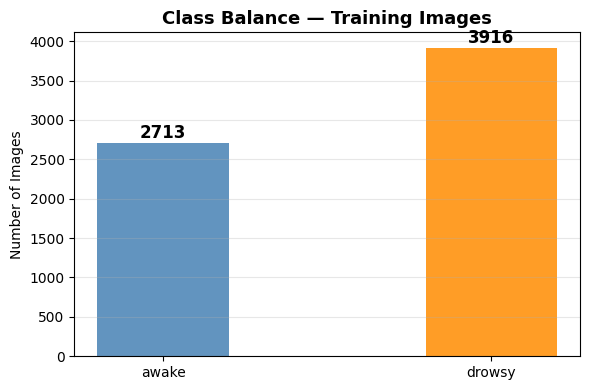

In [ ]:
# ============================================================
# Cell 3: Class Balance Check
# ============================================================
import os, glob, matplotlib.pyplot as plt

def check_class_balance(train_dir):
    extensions = ["*.jpg", "*.jpeg", "*.png"]
    counts = {}

    for cls in sorted(os.listdir(train_dir)):
        cls_path = os.path.join(train_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        n = sum(len(glob.glob(os.path.join(cls_path, ext))) for ext in extensions)
        counts[cls] = n

    total = sum(counts.values())
    classes = list(counts.keys())
    values  = list(counts.values())
    ratio   = values[0] / values[1] if values[1] > 0 else float('inf')

    print(f"\n{'='*45}")
    print(f"  Class Balance — Train Set")
    print(f"{'='*45}")
    print(f"  Total Images : {total}")
    for cls, n in counts.items():
        print(f"  {cls:10s}   : {n:>5}  ({n/total*100:.1f}%)")
    print(f"  Ratio ({classes[0]}/{classes[1]}) : {ratio:.2f}")

    if 0.8 <= ratio <= 1.25:
        verdict = "✅ Balanced — لا تحتاج تعديل"
    elif 0.5 <= ratio < 0.8 or 1.25 < ratio <= 2.0:
        verdict = "⚠️  Slight imbalance — فكر في class_weight"
    else:
        verdict = "❌ Significant imbalance — لازم oversampling أو augmentation!"
    print(f"  {verdict}")
    print(f"{'='*45}")

    # Bar chart
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(classes, values, color=["steelblue", "darkorange"],
                  alpha=0.85, width=0.4)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 5,
                str(h), ha="center", va="bottom", fontsize=12, fontweight="bold")
    ax.set_title("Class Balance — Training Images", fontsize=13, fontweight="bold")
    ax.set_ylabel("Number of Images")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return counts

train_counts = check_class_balance(TRAIN_DIR)

In [ ]:
# ============================================================
# Cell 4: Load + Balance Dataset (النسخة المُصححة)
# ============================================================
import glob
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

def load_and_preprocess_image(path, img_size=IMG_SIZE):
    try:
        img = load_img(path, target_size=img_size)
        img_array = img_to_array(img)
        img_array = img_array / 255.0  # Normalization مهمة لـ MobileNetV2
        return img_array
    except Exception as e:
        print(f"Error loading {path}: {e}")
        return None

def load_images(folder, label, img_size=IMG_SIZE):
    X, y = [], []
    files = (glob.glob(os.path.join(folder, "*.jpg")) +
             glob.glob(os.path.join(folder, "*.jpeg")) +
             glob.glob(os.path.join(folder, "*.png")))

    print(f"Found {len(files)} images in {folder}")

    for path in files:
        processed = load_and_preprocess_image(path, img_size)
        if processed is not None:
            X.append(processed)
            y.append(label)

    print(f"Successfully loaded: {len(X)} images → label={label}")
    return X, y

# ====================== تحميل الصور ======================
X_awake, y_awake = load_images(f'{TRAIN_DIR}/awake', label=0)
X_drowsy, y_drowsy = load_images(f'{TRAIN_DIR}/drowsy', label=1)

# ====================== Augmentation لتوازن الـ Dataset ======================
target = len(X_drowsy)
shortage = target - len(X_awake)

print(f"\nAwake: {len(X_awake)} | Drowsy: {len(X_drowsy)} | Need {shortage} extra Awake")

if shortage > 0:
    aug = ImageDataGenerator(
        rotation_range=15,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2]
    )

    X_awake_arr = np.array(X_awake)

    aug_gen = aug.flow(
        X_awake_arr,
        np.zeros(len(X_awake_arr)),
        batch_size=32,
        shuffle=True
    )

    X_aug = []
    generated = 0
    while generated < shortage:
        batch_X, _ = next(aug_gen)
        for img in batch_X:
            if generated >= shortage:
                break
            X_aug.append(img)
            generated += 1

    print(f"Generated {len(X_aug)} augmented Awake images")

# ====================== دمج + Shuffle ======================
X = np.array(X_awake + X_drowsy + (X_aug if shortage > 0 else []))
y = np.array(y_awake + y_drowsy + ([0] * len(X_aug) if shortage > 0 else []))

# Shuffle
indices = np.random.RandomState(SEED).permutation(len(X))
X = X[indices]
y = y[indices]

print(f"\n✅ Final Dataset:")
print(f"   Awake  (0) : {np.sum(y==0)}")
print(f"   Drowsy (1) : {np.sum(y==1)}")
print(f"   Shape      : {X.shape}")

Found 2713 images in /content/drive/MyDrive/train/awake
Successfully loaded: 2713 images → label=0
Found 3916 images in /content/drive/MyDrive/train/drowsy
Successfully loaded: 3916 images → label=1

Awake: 2713 | Drowsy: 3916 | Need 1203 extra Awake
Generated 1203 augmented Awake images

✅ Final Dataset:
   Awake  (0) : 3916
   Drowsy (1) : 3916
   Shape      : (7832, 96, 96, 3)


In [ ]:
# ============================================================
# Cell 3: تحميل البيانات
# ============================================================

def load_dataset(path):
    ds = tf.keras.utils.image_dataset_from_directory(
        path,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary',
        seed=SEED
    )
    ds = ds.map(lambda x, y: (x / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().prefetch(tf.data.AUTOTUNE)

train_ds = load_dataset(TRAIN_DIR)
val_ds   = load_dataset(VAL_DIR)
test_ds  = load_dataset(TEST_DIR)

# احفظ أسماء الكلاسات قبل أي map/prefetch
raw_test    = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', seed=SEED
)
class_names = raw_test.class_names
print('Classes:', class_names)

# معاينة batch واحد
for imgs, labels in train_ds.take(1):
    print(f'Batch shape: {imgs.shape},  Labels sample: {labels[:5].numpy().flatten()}')

Found 6629 files belonging to 2 classes.
Found 1890 files belonging to 2 classes.
Found 948 files belonging to 2 classes.
Found 948 files belonging to 2 classes.
Classes: ['awake', 'drowsy']
Batch shape: (32, 96, 96, 3),  Labels sample: [1. 1. 1. 1. 0.]


In [ ]:
# ============================================================
# Cell 4: بناء النموذج
# ============================================================
base = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False  # نجمد كل الـ weights في المرحلة الأولى

# Functional API أوضح من Sequential مع base model
inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
x       = base(inputs, training=False)   # training=False مهم مع BatchNorm
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(64, activation='relu')(x)
x       = layers.Dropout(DROPOUT)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs, name='drowsiness_detector')

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "drowsiness_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ============================================================
# Cell 5: التدريب — المرحلة 1 (Head Training)
# ============================================================
print('=' * 50)
print('Phase 1: Training the classification head')
print('=' * 50)

callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, verbose=1
    )
]

history1 = model.fit(
    train_ds,
    epochs=EPOCHS_HEAD,
    validation_data=val_ds,
    callbacks=callbacks_phase1
)

print(f'\nBest val_accuracy (Phase 1): {max(history1.history["val_accuracy"]):.4f}')

Phase 1: Training the classification head
Epoch 1/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 442s 2s/step - accuracy: 0.7511 - loss: 0.4979 - val_accuracy: 0.7799 - val_loss: 0.4385 - learning_rate: 0.0010
Epoch 2/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8264 - loss: 0.3832 - val_accuracy: 0.8169 - val_loss: 0.3860 - learning_rate: 0.0010
Epoch 3/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8599 - loss: 0.3318 - val_accuracy: 0.8582 - val_loss: 0.3349 - learning_rate: 0.0010
Epoch 4/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8724 - loss: 0.3009 - val_accuracy: 0.8640 - val_loss: 0.3248 - learning_rate: 0.0010
Epoch 5/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8828 - loss: 0.2775 - val_accuracy: 0.8677 - val_loss: 0.3252 - learning_rate: 0.0010
Epoch 6/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8911 - loss: 0.2608 - val_accuracy: 0.8725 - val_loss: 0.2955 - learning_rate: 0.0010
Epoch 7/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# ============================================================
# Cell 6: التدريب — المرحلة 2 (Fine-Tuning)
# ============================================================
print('=' * 50)
print(f'Phase 2: Fine-tuning last {FINE_TUNE_AT} layers')
print('=' * 50)

base.trainable = True

# اجمد كل حاجة غير آخر FINE_TUNE_AT layer
for layer in base.layers[:-FINE_TUNE_AT]:
    layer.trainable = False

trainable_count = sum(1 for l in base.layers if l.trainable)
print(f'Trainable layers in base: {trainable_count} / {len(base.layers)}')

# learning rate أصغر بكتير للـ fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=4,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1
    )
]

history2 = model.fit(
    train_ds,
    epochs=EPOCHS_FT,
    validation_data=val_ds,
    callbacks=callbacks_phase2
)

# حفظ الـ history كـ JSON عشان نقدر نحمله في session جديدة
with open(HISTORY_PATH, 'w') as f:
    json.dump({'h1': history1.history, 'h2': history2.history}, f)

print(f'\nBest val_accuracy (Phase 2): {max(history2.history["val_accuracy"]):.4f}')
print('Model & history saved!')

Phase 2: Fine-tuning last 20 layers
Trainable layers in base: 20 / 154
Epoch 1/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7615 - loss: 0.6589
Epoch 1: val_accuracy improved from None to 0.89259, saving model to /content/drive/MyDrive/drowsiness_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/drowsiness_model.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 35s 94ms/step - accuracy: 0.7968 - loss: 0.5381 - val_accuracy: 0.8926 - val_loss: 0.2878
Epoch 2/10
206/208 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8493 - loss: 0.3462
Epoch 2: val_accuracy improved from 0.89259 to 0.89630, saving model to /content/drive/MyDrive/drowsiness_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/drowsiness_model.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8570 - loss: 0.3333 - val_accuracy: 0.8963 - val_loss: 0.2909
Epoch 3/10
204/208 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8896 - loss: 0.2604
Epoch 3: val_accuracy did not improv

In [ ]:
# ============================================================
# Cell 7: تقييم النموذج على الـ Test Set
# ============================================================
loss, acc = model.evaluate(test_ds, verbose=1)
print(f'\nTest Accuracy : {acc * 100:.2f}%')
print(f'Test Loss     : {loss:.4f}')

30/30 ━━━━━━━━━━━━━━━━━━━━ 227s 8s/step - accuracy: 0.8776 - loss: 0.3017

Test Accuracy : 87.76%
Test Loss     : 0.3017


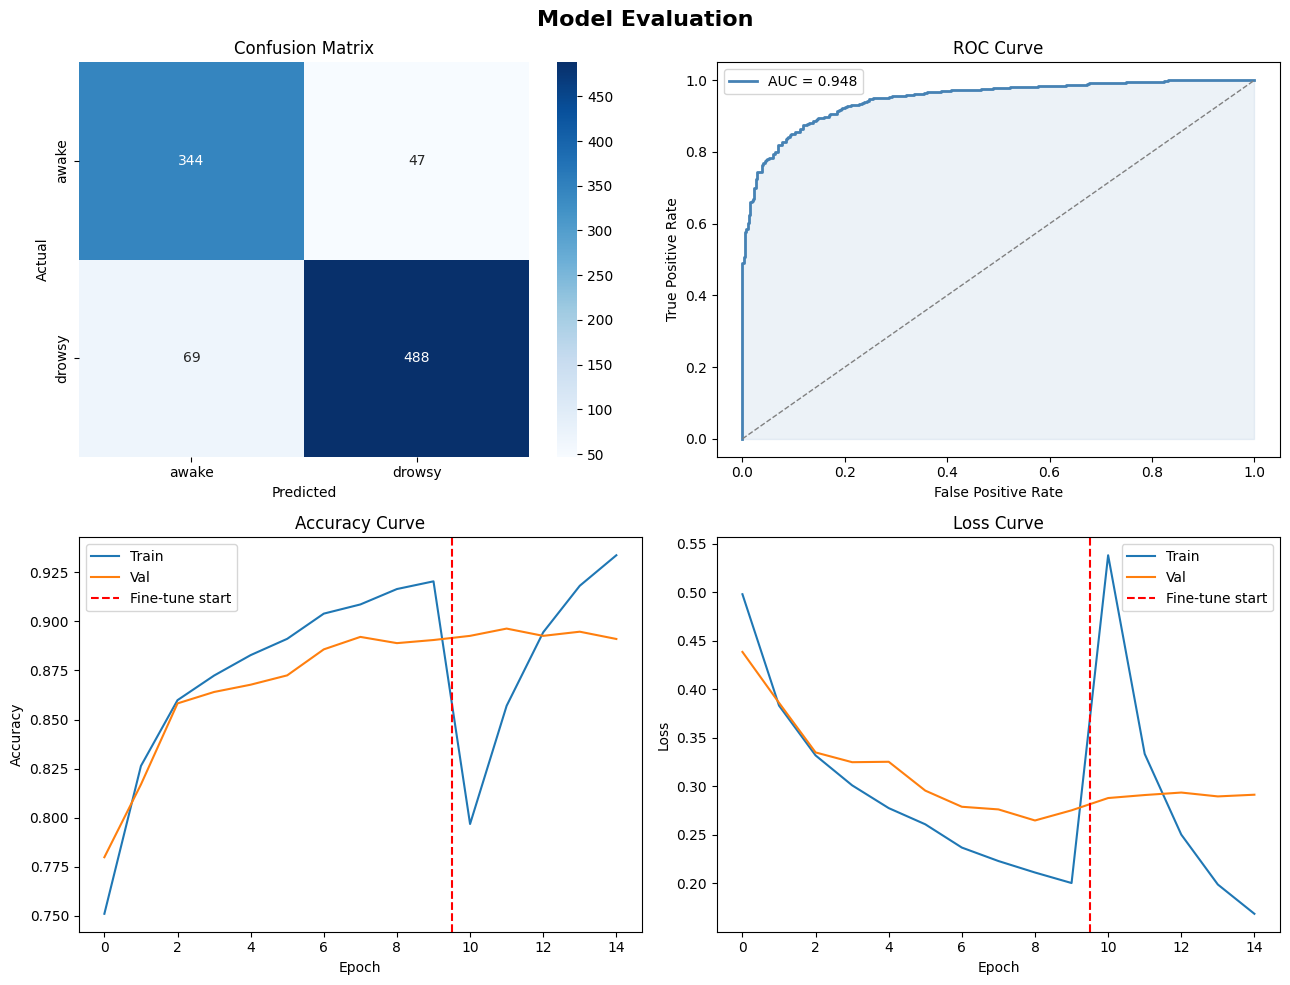


Classification Report
              precision    recall  f1-score   support

       awake       0.83      0.88      0.86       391
      drowsy       0.91      0.88      0.89       557

    accuracy                           0.88       948
   macro avg       0.87      0.88      0.87       948
weighted avg       0.88      0.88      0.88       948



In [ ]:
# ============================================================
# Cell 8: الـ Evaluation الشامل
# ============================================================


# تحميل الـ history
with open(HISTORY_PATH, 'r') as f:
    h = json.load(f)
h1, h2 = h['h1'], h['h2']

# جمع predictions
y_true, y_pred_probs = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds.flatten())
    y_true.extend(labels.numpy().astype(int).flatten())

y_pred = (np.array(y_pred_probs) > 0.5).astype(int)

# رسم الـ 4 charts في figure واحدة
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Model Evaluation', fontsize=16, fontweight='bold')

# 1. Confusion Matrix
ax = axes[0, 0]
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

# 2. ROC Curve
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.set_title('ROC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()

# 3. Accuracy Curve
ax = axes[1, 0]
split       = len(h1['accuracy'])
acc_all     = h1['accuracy']     + h2['accuracy']
val_acc_all = h1['val_accuracy'] + h2['val_accuracy']
ax.plot(acc_all,     label='Train')
ax.plot(val_acc_all, label='Val')
ax.axvline(x=split - 0.5, color='red', linestyle='--', label='Fine-tune start')
ax.set_title('Accuracy Curve')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()

# 4. Loss Curve
ax = axes[1, 1]
loss_all     = h1['loss']     + h2['loss']
val_loss_all = h1['val_loss'] + h2['val_loss']
ax.plot(loss_all,     label='Train')
ax.plot(val_loss_all, label='Val')
ax.axvline(x=split - 0.5, color='red', linestyle='--', label='Fine-tune start')
ax.set_title('Loss Curve')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()

plt.tight_layout()
plt.show()

# Classification Report
print('\n' + '=' * 50)
print('Classification Report')
print('=' * 50)
print(classification_report(y_true, y_pred, target_names=class_names))